In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

data = pd.read_parquet("hf://datasets/turk/simplification/")

def expand_data(df):
    new_rows = []
    for _, row in df.iterrows():
        for s in row['simplifications']:
            new_rows.append({'original': row['original'], 'simplification': s})
    return pd.DataFrame(new_rows)

df_train = expand_data(data[:2000])
df_test_raw = data[2000:].reset_index(drop=True)

df_test = df_test_raw.copy()
df_test["simplifications"] = df_test["simplifications"].apply(lambda refs: [s for s in refs if isinstance(s, str)])

df_train['original'] = df_train['original'].str.lower().str.strip()
df_train['simplification'] = df_train['simplification'].str.lower().str.strip()

df_train = df_train[df_train['original'].str.split().str.len() <= 100].reset_index(drop=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:

from datasets import Dataset
from transformers import BartTokenizer

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")
hf_dataset = Dataset.from_pandas(df_train[["original", "simplification"]])

def preprocess(example):
    input_text = example["original"]
    target_text = example["simplification"]
    model_inputs = tokenizer(input_text, max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(target_text, max_length=128, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = hf_dataset.map(preprocess, batched=False)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.63k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

In [ ]:

from transformers import BartForConditionalGeneration, TrainingArguments, Trainer

model = BartForConditionalGeneration.from_pretrained("facebook/bart-large")

training_args = TrainingArguments(
    output_dir="./results_bart",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs_bart",
    logging_steps=10,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset
)

trainer.train()


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Step,Training Loss
10,10.781000
20,8.337400
30,5.969900
40,4.665700
50,3.715300
60,2.830700
70,1.913500
80,1.088500
90,0.524500
100,0.294600


TrainOutput(global_step=6000, training_loss=0.20785693640510242, metrics={'train_runtime': 5451.4228, 'train_samples_per_second': 8.805, 'train_steps_per_second': 1.101, 'total_flos': 1.3002627612672e+16, 'train_loss': 0.20785693640510242, 'epoch': 3.0})

In [ ]:
# 7️⃣ Guardado correcto del modelo y tokenizer
model.save_pretrained("/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification")
tokenizer.save_pretrained("/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification")

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3464: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification/tokenizer_config.json',
 '/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification/special_tokens_map.json',
 '/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification/vocab.json',
 '/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification/merges.txt',
 '/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification/added_tokens.json')

In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer

model_path = "/content/drive/MyDrive/TextSimplification/bart-TC-finetuned-simplification"

model = BartForConditionalGeneration.from_pretrained(model_path)
tokenizer = BartTokenizer.from_pretrained(model_path)

In [ ]:
def generate_simplification(text):
    input_ids = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128).input_ids
    input_ids = input_ids.to(model.device)
    output_ids = model.generate(input_ids, max_length=128, num_beams=4, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

df_test["generated"] = df_test["original"].apply(generate_simplification)

In [ ]:

for i in range(5):
    print(f"Original: {df_test.loc[i, 'original']}")
    print(f"Generated: {df_test.loc[i, 'generated']}")
    print(f"References: {df_test.loc[i, 'simplifications']}")
    print("-" * 50)


Original: the contemporary status of the mandaeans has prompted a number of american intellectuals and civil rights activists to call for their government to extend refugee status to the community .
Generated: the current status of the mandaeans has caused a number of american intellectuals and civil rights activists to call for their government to extend refugee status to the community .
References: ['a number of american civil rights activists and intellectuals have called for their government to extend refugee status to the mandaeans .', 'the current status of the mandaeans has caused a number of american intellectuals and civil rights activists to call for their government to extend refugee status to the community .', 'the standing , today , of those that practice the ancient religion , known as mandaeism , has led a lot of american intellectuals and civil rights activists to call to their governmen to offer refugee status to the community .', 'the status of the mandaenas has promp

In [ ]:
!git clone https://github.com/feralvam/easse.git
%cd easse
!pip install -e .

Cloning into 'easse'...
remote: Enumerating objects: 1964, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 1964 (delta 109), reused 96 (delta 96), pack-reused 1827 (from 1)
Receiving objects: 100% (1964/1964), 33.15 MiB | 27.55 MiB/s, done.
Resolving deltas: 100% (1231/1231), done.
/content/easse
Obtaining file:///content/easse
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/facebookresearch/text-simplification-evaluation.git (to revision main) to /tmp/pip-install-uh16jr_2/tseval_0faccc771ac9497480f5a88d99d0d54e
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/text-simplification-evaluation.git /tmp/pip-install-uh16jr_2/tseval_0faccc771ac9497480f5a88d99d0d54e
  Resolved https://github.com/facebookresearch/text-simplification-evaluation.git to commit dea8863683ea5946fd50184883c9be7a7339e821
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━

In [ ]:

from easse.sari import corpus_sari
from easse.bleu import sentence_bleu
from easse.fkgl import corpus_fkgl
import numpy as np
from tqdm.auto import tqdm
import nltk
nltk.download('punkt_tab')

df_eval = df_test.dropna(subset=["generated"]).reset_index(drop=True)

saris = []
bleus = []

for i in tqdm(range(len(df_eval))):
    sari_score = corpus_sari(
        orig_sents=[df_eval.loc[i, "original"]],
        sys_sents=[df_eval.loc[i, "generated"]],
        refs_sents=[[ref] for ref in df_eval.loc[i, "simplifications"]],
        use_paper_version=True
    )
    saris.append(sari_score)

    bleu_score = sentence_bleu(
        sys_sent=df_eval.loc[i, "generated"],
        ref_sents=df_eval.loc[i, "simplifications"]
    )
    bleus.append(bleu_score)

fkgl_score = corpus_fkgl(df_eval["generated"].tolist())

print(f"SARI (↑): {np.mean(saris):.3f}")
print(f"BLEU (↑): {np.mean(bleus):.3f}")
print(f"FKGL (↓): {fkgl_score:.3f}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


  0%|          | 0/359 [00:00<?, ?it/s]

SARI (↑): 32.149
BLEU (↑): 96.030
FKGL (↓): 9.352


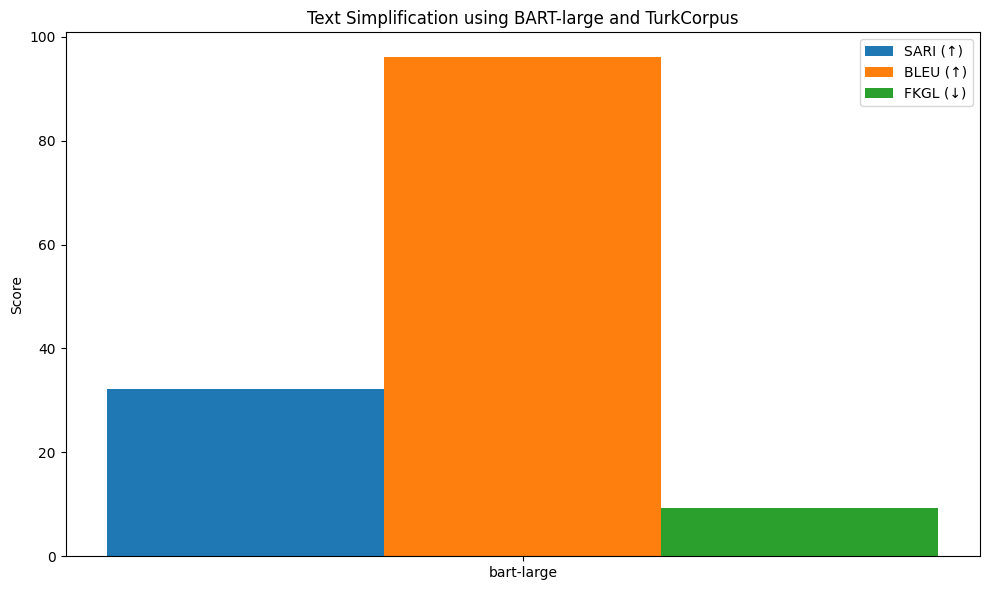

In [ ]:
import matplotlib.pyplot as plt
import os

results_file = "/mnt/data/model_comparison_results.csv"

def save_model_result(model_name, sari, bleu, fkgl):
    if os.path.exists(results_file):
        df = pd.read_csv(results_file)
    else:
        df = pd.DataFrame(columns=["Model", "SARI", "BLEU", "FKGL"])
    df = df[df["Model"] != model_name]
    df.loc[len(df)] = [model_name, sari, bleu, fkgl]
    df.to_csv(results_file, index=False)
    return df

os.makedirs("/mnt/data", exist_ok=True)

df_updated = save_model_result(
    "bart-large",
    np.mean(saris),
    np.mean(bleus),
    fkgl_score
)

labels = df_updated['Model']
sari = df_updated['SARI']
bleu = df_updated['BLEU']
fkgl = df_updated['FKGL']

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, sari, width, label='SARI (↑)')
ax.bar(x, bleu, width, label='BLEU (↑)')
ax.bar(x + width, fkgl, width, label='FKGL (↓)')

ax.set_ylabel('Score')
ax.set_title('Text Simplification using BART-large and TurkCorpus')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download("/mnt/data/model_comparison_results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df_updated.to_csv("/content/drive/MyDrive/TextSimplification/model_comparison_results.csv", index=False)
